# Candidate Ranking EDA
This notebook provides snippets to analyze the extracted features from candidates against the labels you've collected.

In [13]:
import json
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rank import iter_candidates, build_memo, xgb_features_from_memo
from scorer import jd_fit_score, recruitability_score

## 1. Load Data
We will load the labels from `labels.csv` and extract features for those specific candidates from `candidatesphase2.jsonl`.

In [14]:
# 1. Load labels from labels.csv
# Your labels.csv should have two columns: 'candidate_id' and 'relevance' (e.g., 0 to 4)
labels_df = pd.read_csv('labels.csv')
label_map = dict(zip(labels_df['candidate_id'], labels_df['relevance']))

# 2. Extract features for labeled candidates from candidatesphase2.jsonl
rows = []
feature_names = [
    'jd_fit_score', 'recruitability_score', 'yoe', 'is_research_only',
    'is_job_hopper', 'is_big_tech_lifer', 'has_production_keywords',
    'notice_days', 'response_rate', 'matched_skills', 'location_note'
]

input_file = 'candidatesphase2.jsonl'

try:
    for cand in iter_candidates(input_file):
        cid = cand.get('candidate_id')
        if cid in label_map:
            jd_fit = jd_fit_score(cand)
            rec = recruitability_score(cand)
            memo = build_memo(cand, jd_fit, rec, jd_fit * rec)
            features = xgb_features_from_memo(memo)
            
            row_dict = dict(zip(feature_names, features))
            row_dict['candidate_id'] = cid
            row_dict['relevance'] = label_map[cid]
            rows.append(row_dict)
except FileNotFoundError:
    print(f"Warning: {input_file} not found.")

df = pd.DataFrame(rows)
df.head()

,jd_fit_score,recruitability_score,yoe,is_research_only,is_job_hopper,is_big_tech_lifer,has_production_keywords,notice_days,response_rate,matched_skills,location_note,candidate_id,relevance
0,17.00,0.527601,6.1,0.0,0.0,0.0,0.0,60.0,0.88,5.0,1.0,CAND_0046525,4
1,16.20,0.523029,6.9,0.0,0.0,0.0,0.0,15.0,0.50,5.0,1.0,CAND_0037566,4
2,14.95,0.526775,5.4,0.0,0.0,0.0,1.0,45.0,0.78,5.0,0.0,CAND_0030468,4
3,15.95,0.488191,8.8,0.0,0.0,0.0,1.0,0.0,0.66,5.0,0.0,CAND_0080766,4
4,17.00,0.455016,8.0,0.0,0.0,0.0,0.0,60.0,0.77,5.0,1.0,CAND_0041669,4


## 2. Feature Correlation
Check how individual features correlate with the relevance label.

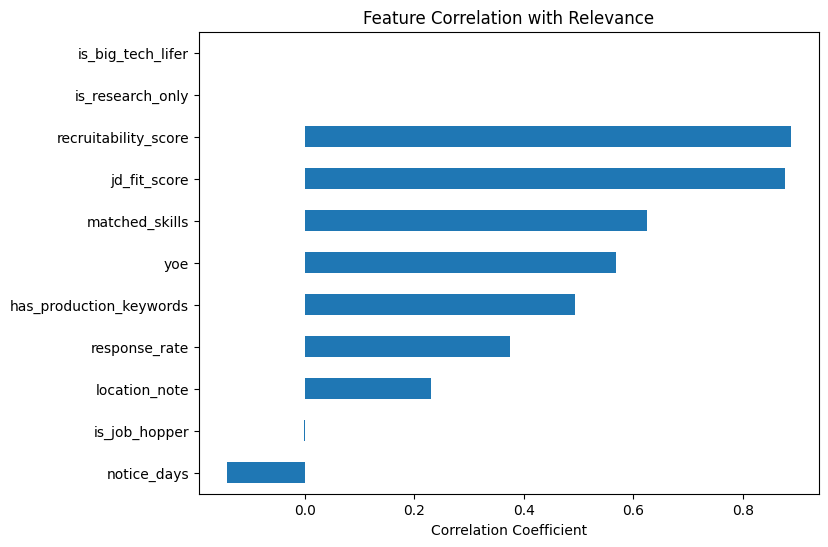

In [15]:
if not df.empty:
    # Calculate correlation matrix
    corr = df[feature_names + ['relevance']].corr()
    
    # Plot correlation with relevance
    plt.figure(figsize=(8, 6))
    corr['relevance'].drop('relevance').sort_values().plot(kind='barh')
    plt.title('Feature Correlation with Relevance')
    plt.xlabel('Correlation Coefficient')
    plt.show()

## 3. Score Distributions
See how the heuristic scores separate the labeled relevance tiers.

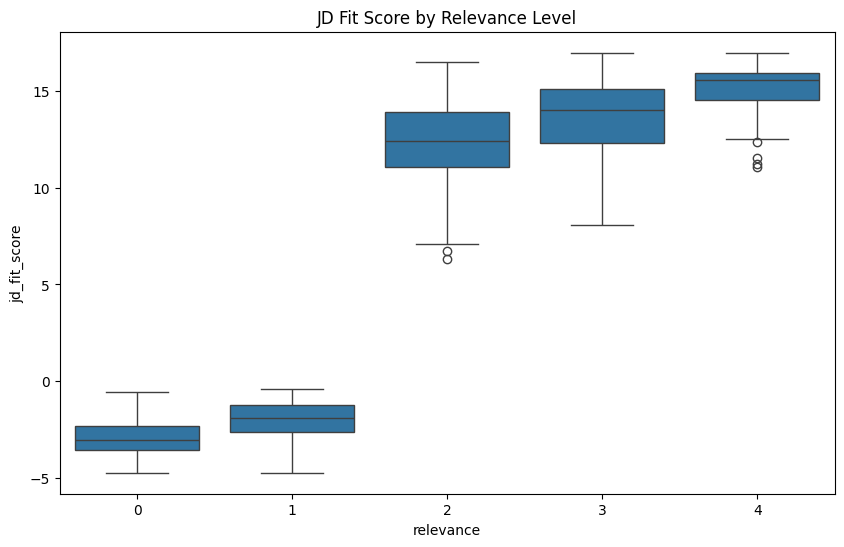

In [16]:
if not df.empty:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='relevance', y='jd_fit_score', data=df)
    plt.title('JD Fit Score by Relevance Level')
    plt.show()